В данном проекте исследуется влияние новостей на динамику цен карбамида (азотное удобрение).

**Цель:** определить, улучшают ли рыночные новости прогнозирование цен на карбамид (urea_price) и какие типы новостей содержат наиболее полезную информацию.

## Загрузка данных

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.base import clone, BaseEstimator, RegressorMixin
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    root_mean_squared_error as rmse, 
    mean_absolute_error as mae, 
    mean_absolute_percentage_error as mape)
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from collections import defaultdict
import shap
import pymorphy3
import nltk
from nltk.corpus import stopwords

In [2]:
news = pd.read_csv('data/market_news.csv')
prices = pd.read_csv('data/prices.csv')

In [3]:
print(news.info())
news.head()

<class 'pandas.DataFrame'>
RangeIndex: 370 entries, 0 to 369
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   date      370 non-null    str  
 1   source    370 non-null    str  
 2   category  370 non-null    str  
 3   headline  370 non-null    str  
dtypes: str(4)
memory usage: 11.7 KB
None


,date,source,category,headline
0,2020-01-08,Интерфакс,Прочее,Опубликован годовой ESG-отчёт компании
1,2020-01-10,CRU,Фосфаты,DAP дешевеет из-за слабого спроса в Индии
2,2020-01-18,Профильный телеграм-канал,Логистика,"Ставки фрахта снижаются, логистика дешевеет"
3,2020-03-12,ICIS,Аммиак,Котировки аммиака пошли вниз на фоне слабого с...
4,2020-03-14,CRU,Прочее,Компания провела ежегодный день инвестора


In [4]:
print(prices.info())
prices.head(3)

<class 'pandas.DataFrame'>
RangeIndex: 339 entries, 0 to 338
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date                  339 non-null    str    
 1   urea_price            339 non-null    float64
 2   dap_price             339 non-null    float64
 3   mop_price             339 non-null    float64
 4   gas_price             326 non-null    float64
 5   ammonia_price         339 non-null    float64
 6   brent_oil             339 non-null    float64
 7   usd_rub               339 non-null    float64
 8   freight_index         326 non-null    float64
 9   crop_price_index      339 non-null    float64
 10  sulphur_price         326 non-null    float64
 11  phosphate_rock_price  339 non-null    float64
 12  potash_supply_index   339 non-null    float64
 13  consensus_price_urea  339 non-null    float64
dtypes: float64(13), str(1)
memory usage: 37.2 KB
None


,date,urea_price,dap_price,mop_price,gas_price,ammonia_price,brent_oil,usd_rub,freight_index,crop_price_index,sulphur_price,phosphate_rock_price,potash_supply_index,consensus_price_urea
0,2020-01-06,378.4,600.0,464.1,28.0,486.0,72.5,65.02,2000.0,104.4,140.0,170.0,100.0,337.8
1,2020-01-13,338.2,564.2,457.7,25.4,423.5,71.4,64.68,1934.0,103.9,148.8,167.5,98.5,357.5
2,2020-01-20,365.6,553.7,484.5,27.7,458.6,72.1,65.34,1887.0,109.8,141.5,150.7,98.6,366.5


Преобразуем дату из строки в datetime формат

In [5]:
prices = prices.set_index(pd.to_datetime(prices.date)).drop(columns='date')
news = news.set_index(pd.to_datetime(news.date)).drop(columns='date')

news.index, prices.index

(DatetimeIndex(['2020-01-08', '2020-01-10', '2020-01-18', '2020-03-12',
                '2020-03-14', '2020-03-18', '2020-03-20', '2020-04-04',
                '2020-04-06', '2020-04-08',
                ...
                '2026-04-10', '2026-04-20', '2026-05-07', '2026-05-13',
                '2026-05-15', '2026-05-16', '2026-05-29', '2026-06-12',
                '2026-06-25', '2026-07-01'],
               dtype='datetime64[us]', name='date', length=370, freq=None),
 DatetimeIndex(['2020-01-06', '2020-01-13', '2020-01-20', '2020-01-27',
                '2020-02-03', '2020-02-10', '2020-02-17', '2020-02-24',
                '2020-03-02', '2020-03-09',
                ...
                '2026-04-27', '2026-05-04', '2026-05-11', '2026-05-18',
                '2026-05-25', '2026-06-01', '2026-06-08', '2026-06-15',
                '2026-06-22', '2026-06-29'],
               dtype='datetime64[us]', name='date', length=339, freq=None))

Убедимся в том, что новости и цены отсортированы по дате

In [6]:
print(prices.index.is_monotonic_increasing)
print(news.index.is_monotonic_increasing)

True
True


## EDA цен (prices.csv)

### Проверка качества данных

Проверка на пропуски:

In [7]:
prices.isna().sum()

urea_price               0
dap_price                0
mop_price                0
gas_price               13
ammonia_price            0
brent_oil                0
usd_rub                  0
freight_index           13
crop_price_index         0
sulphur_price           13
phosphate_rock_price     0
potash_supply_index      0
consensus_price_urea     0
dtype: int64

In [8]:
cols_with_nans = [col for col in prices.columns if prices[col].isna().sum() != 0]
cols_with_nans

['gas_price', 'freight_index', 'sulphur_price']

В колонках `gas_price`, `freight_index` и `sulphur_price` ровно по 13 пропусков. Посмотрим, есть ли между ними какая-то связь, например, идут ли они подряд или встречаются одновременно в нескольких колонках

In [9]:
prices[prices.isna().any(axis=1)][cols_with_nans]

,gas_price,freight_index,sulphur_price
date,,,
2020-02-17,23.3,1744.0,NaN
2020-03-16,25.4,NaN,NaN
2020-04-20,28.9,NaN,130.6
2020-04-27,29.6,2168.0,NaN
2020-08-24,29.1,1778.0,NaN
2020-09-28,NaN,1718.0,103.7
2020-10-12,NaN,2079.0,115.0
2020-11-23,33.1,2054.0,NaN
2021-03-22,40.6,3141.0,NaN


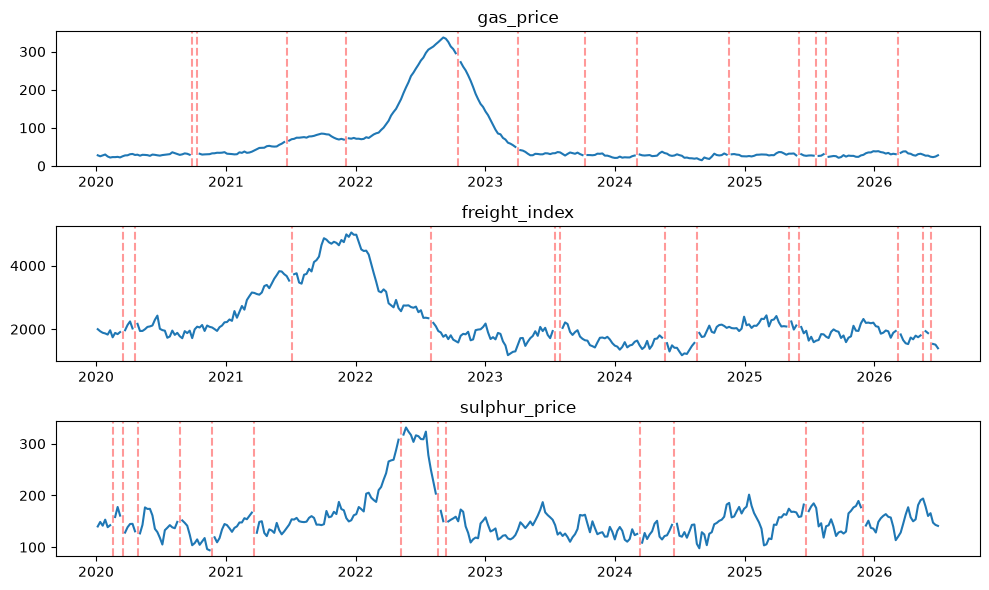

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(10, 6))
axes = axes.flatten()
for i, col in enumerate(cols_with_nans):
    axes[i].plot(prices.index, prices[col])
    nan_dates = prices[prices[col].isna()].index
    for date in nan_dates:
        axes[i].axvline(date, color='red', alpha=0.4, linestyle='--')
    axes[i].set_title(col)
    
plt.tight_layout()

На графиках видно, что пропуски разбросаны хаотично и редко встречаются в разных колонках в одни и те же даты. Поскольку некоторые современные модели (CatBoost) умеют работать с пропущенными данными, поэтому их можно оставить, а для конкретных моделей (линейная регрессия) использовать заполнение предыдущим значением (`ffill`)

Проверим данные на дубликаты:

In [11]:
if prices.index.is_unique:
    print("На одну дату приходится только одна строка, данные не повторяются")
else:
    print("Есть повторяющиеся даты")

На одну дату приходится только одна строка, данные не повторяются


Проверка непрерывности временного ряда:

In [12]:
prices.index.diff().value_counts()

date
7 days    338
Name: count, dtype: int64

### Корреляционный анализ

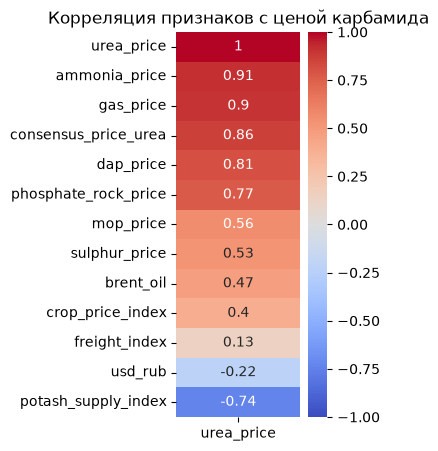

In [13]:
corr_matrix = prices.select_dtypes(include='number').corr()

urea_corr = corr_matrix[['urea_price']].sort_values(by='urea_price', ascending=False)

plt.figure(figsize=(2, 5))
sns.heatmap(urea_corr, annot=True, cmap='coolwarm',  vmin=-1, vmax=1)
plt.title('Корреляция признаков с ценой карбамида');

Цена карбамида сильнее всего связана с ценами на аммиак и газ, что ожидаемо, поскольку они напрямую связаны с его производством. Также заметна связь с другими рыночными показателями, отражающими общую ситуацию на рынке.

### Анализ временных рядов и выявление аномалий

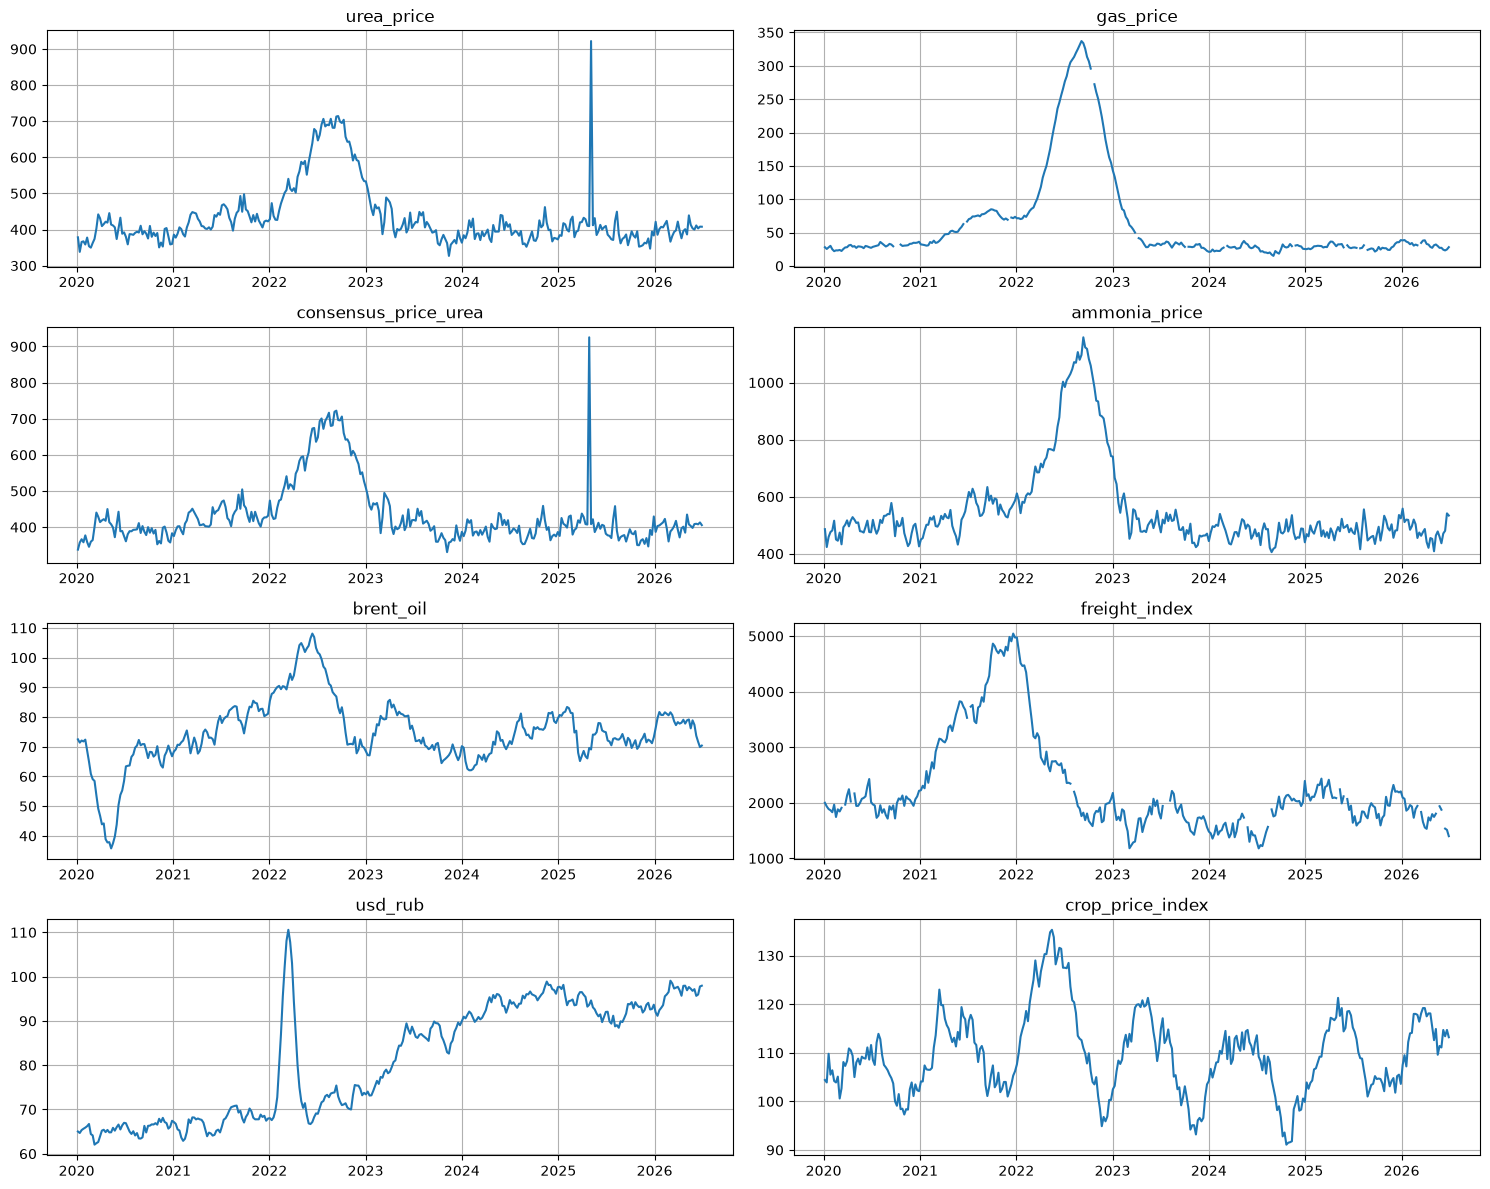

In [14]:
key_features = [
    'urea_price',           # целевой признак - цена карбамида (азотного удобрения)
    'gas_price',            # цена природного газа - сырье для аммиака
    'consensus_price_urea', # консенсус-оценка цены карбамида
    'ammonia_price',        # цена аммиака - полупродукт для азотных удобрений
    'brent_oil',            # стоимость нефти - влияет на логистику и добычу сырья
    'freight_index',        # стоимость морских перевозок
    'usd_rub',              # доллар к рублю, влияет, так как Россия - один из крупнейших экспортеров
    'crop_price_index'      # индекс цен на агрокультуры (прокси спроса на удобрения)
]

fig, axes = plt.subplots(4, 2, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(key_features):
    axes[i].plot(prices.index, prices[col])
    axes[i].set_title(col)
    axes[i].grid()

for j in range(len(key_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

Цена карбамида (`urea_price`) имеет выраженный рост в 2022 году, после которого возвращается к более стабильным значениям. Аналогичную динамику демонстрируют цены на газ и аммиак, что согласуется с гипотезой о сильной зависимости цены карбамида от стоимости сырья. 

В целевой переменной `urea_price` (и связанной `consensus_price_urea`) обнаружен экстремальный выброс в 2025 году.

График `crop_price_index` (индекс цен на агрокультуры) демонстрирует стабильную годовую сезонность, поэтому данный признак потенциально может помочь модели учитывать цикличность спроса.

В столбцах `brent_oil` и `usd_rub` присутствуют отдельные аномальные наблюдения. На данном этапе они не удаляются, так как могут отражать реальные рыночные события.

In [15]:
anomaly_date = prices[prices['urea_price'] > 750].index[0]

prices.loc[
    anomaly_date - pd.Timedelta(weeks=3) : anomaly_date + pd.Timedelta(weeks=3), 
    ['urea_price', 'consensus_price_urea']
]

,urea_price,consensus_price_urea
date,,
2025-04-14,428.5,408.4
2025-04-21,410.4,407.2
2025-04-28,409.5,925.3
2025-05-05,922.0,408.3
2025-05-12,412.0,421.8
2025-05-19,431.6,386.4
2025-05-26,384.8,397.5


<Axes: xlabel='date'>

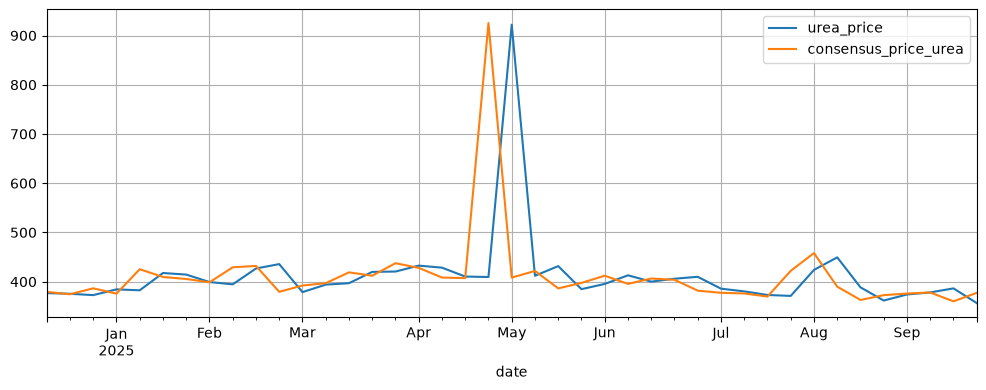

In [16]:
anomaly_slice = prices.loc[
    anomaly_date - pd.Timedelta(weeks=20) : anomaly_date + pd.Timedelta(weeks=20), 
    ['urea_price', 'consensus_price_urea']
]

anomaly_slice[['urea_price', 'consensus_price_urea']].plot(figsize=(12, 4), grid=True)

Анализ показал, что аномалия в urea_price была предсказана консенсус-прогнозом за одну неделю до события. Это говорит о том, что экстремальное значение, возможно, не является ошибкой в данных, поэтому его необходимо оставить. Возможно, мы сможем достать полезную информацию из новостей за этот период.

In [17]:
pd.set_option('display.max_colwidth', None)

news.query("'2025-04-01' <= index <= '2025-05-15'")[['category', 'headline']]

,category,headline
date,,
2025-04-01,Спрос/агрорынок,Высокие цены на агрокультуры стимулируют закупки удобрений фермерами
2025-04-10,Логистика,Логистические издержки растут — дорожает доставка удобрений
2025-04-12,Энергоносители,Газ дорожает на фоне перебоев с поставками — растёт себестоимость азотных удобрений
2025-04-18,Прочее,Отраслевая конференция по удобрениям пройдёт в следующем месяце
2025-04-22,Фосфаты,Фосфатное сырьё дорожает вслед за серой
2025-05-10,Калий,Новые контракты по калию заключены ниже рынка
2025-05-14,Фосфаты,Снижение цен на серу тянет вниз котировки фосфатных удобрений
2025-05-15,Энергоносители,Газ дешевеет вторую неделю подряд
2025-05-15,Спрос/агрорынок,Фермеры откладывают закупки удобрений


В рассматриваемом временном интервале не обнаружено значимых новостных событий, аварий на производстве или иных факторов, которые могли бы объяснить столь резкое изменение цены карбамида.

Построим графики тренда и сезонности движения цены

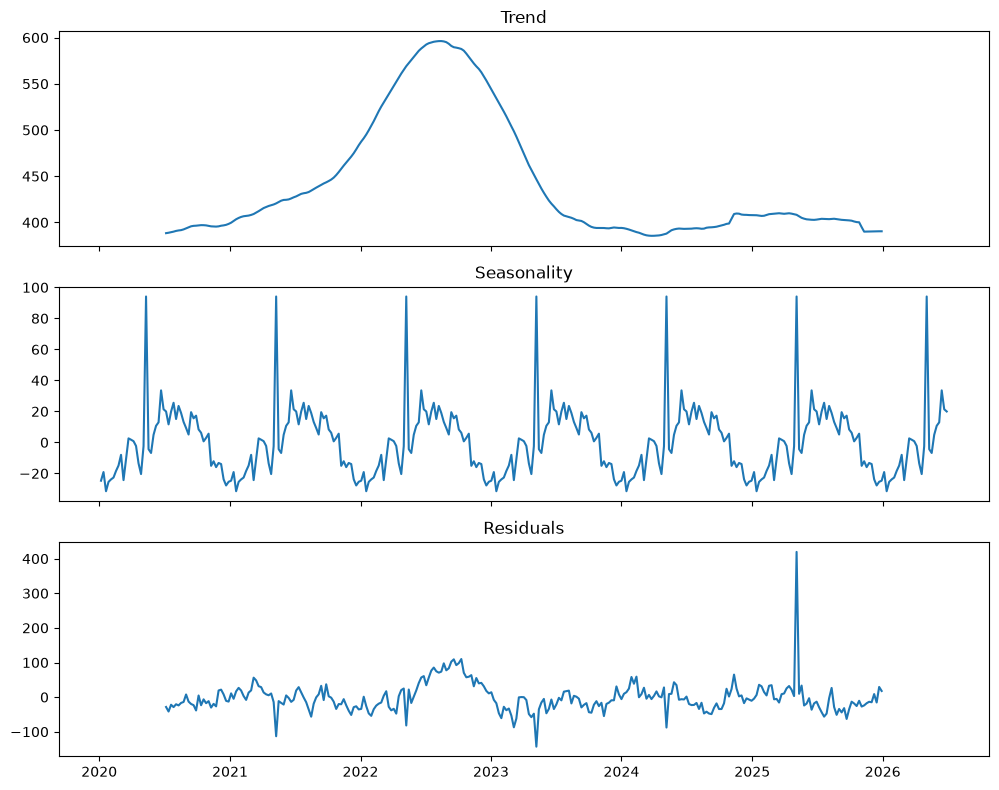

In [18]:
decomposed = seasonal_decompose(prices.urea_price)

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
axes[0].plot(decomposed.trend)
axes[0].set_title('Trend')
axes[1].plot(decomposed.seasonal)
axes[1].set_title('Seasonality')
axes[2].plot(decomposed.resid)
axes[2].set_title('Residuals')
plt.tight_layout()

На графике видна годовая сезонность, проверим, действительно ли она есть

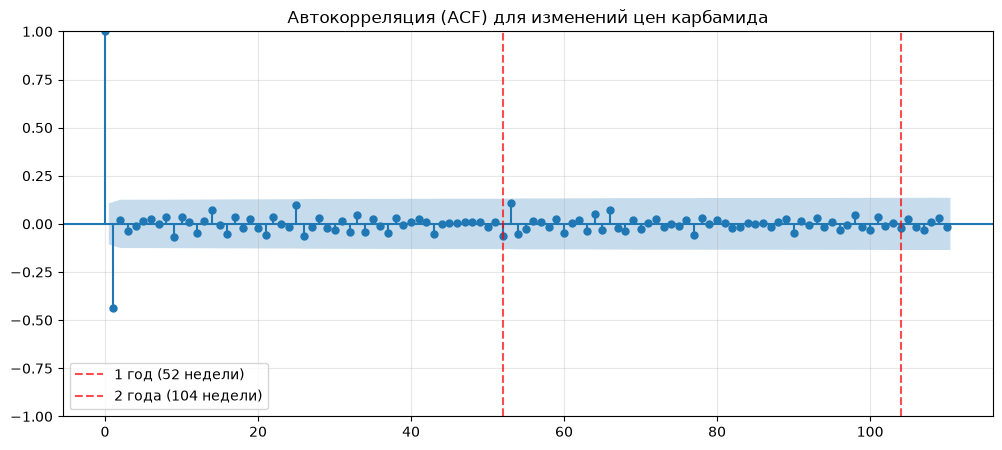

In [19]:
plt.figure(figsize=(12, 5))
plot_acf(prices.urea_price.diff().dropna(), lags=110, ax=plt.gca())
plt.title('Автокорреляция (ACF) для изменений цен карбамида')
plt.axvline(52, color='red', linestyle='--', alpha=0.7, label='1 год (52 недели)')
plt.axvline(104, color='red', linestyle='--', alpha=0.7, label='2 года (104 недели)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

График автокорреляции показывает, что годовой сезонности нет (лаги 52 и 104 недель слабо каррелируют с текущей ценой), а вот изменения за последние 1-2 недели являются главными предикторами и могут быть очень полезны для модели

C:\Temp\ipykernel_9916\2011388418.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_box, x='month', y='urea_price', palette='coolwarm')


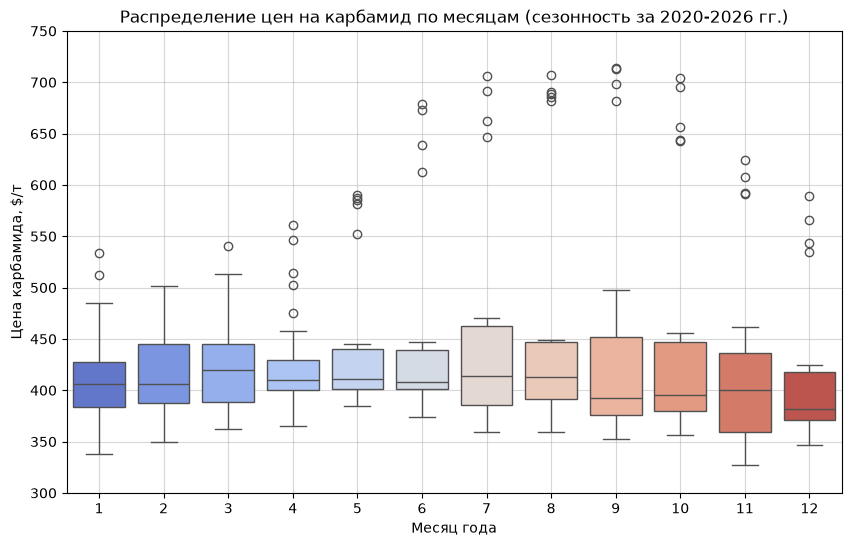

In [20]:
df_box = prices[['urea_price']].copy()
df_box['month'] = df_box.index.month

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_box, x='month', y='urea_price', palette='coolwarm')
plt.title('Распределение цен на карбамид по месяцам (сезонность за 2020-2026 гг.)')
plt.xlabel('Месяц года')
plt.ylabel('Цена карбамида, $/т')
plt.ylim(300, 750)
plt.grid(True, alpha=0.5)

График наглядно подтверждает результаты автокорреляционного анализа (ACF): у цен на карбамид нет устойчивой внутренней сезонности.

Группа выбросов с июня по октябрь ($600–$700+) — это отражение затяжного сырьевого кризиса 2022 года.

## Построение моделей (без использования новостей)

In [21]:
class TimeSeriesEvaluator:
    """
    Класс для автоматизации кросс-валидации моделей на временных рядах.
    """
    def __init__(self, n_splits=4, metrics=None):
        """      
        Parameters:
        -----------
        n_splits : int, default 4
            Количество фолдов для TimeSeriesSplit.
        metrics : list of tuples/functions, optional
            Список метрик в формате [('Name', function), ...] или [function, ...].
            Если None, по умолчанию используются MAE, MAPE и RMSE.
        """
        self.n_splits = n_splits
        self.splitter = TimeSeriesSplit(n_splits=n_splits)
        
        if metrics is None:

            self.metrics = [
                ('MAE', mae),
                ('MAPE', mape),
                ('RMSE', rmse)
            ]
        else:
            self.metrics = metrics
            
        self.results = {}

    def evaluate(self, model, X, y, fit_params=None, name=None, target_transform=None, current_price_col='urea_price', preprocessor=None):
        """
        Запускает кросс-валидацию для модели.
        
        Parameters:
        -----------
        model : estimator
            Объект модели (совместимый с API scikit-learn).
        X : pd.DataFrame
            Матрица признаков.
        y : pd.Series
            Вектор таргета.
        fit_params : dict, optional
            Статические параметры для fit() (общие для всех фолдов).
        target_transform : str, optional
            Если 'diff', модель обучается на приращениях (y - X[current_price_col]),
            а метрики рассчитываются на восстановленной цене.
        current_price_col : str, default 'urea_price'
            Имя колонки с текущей ценой для расчета разностей.
        preprocessor : estimator, optional
            Препроцессор (например, ColumnTransformer с PCA), который будет 
            обучаться только на train фолде и применяться к train и val.
        """
        scores = defaultdict(list)
        fitted_models = []
        val_predictions = []
        val_indices = []
        
        base_fit_params = fit_params.copy() if fit_params is not None else {}
        
        model_name = name if name is not None else model.__class__.__name__

        for fold, (train_idx, val_idx) in enumerate(self.splitter.split(X)):
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
            
            # Сохраняем значения текущей цены для реконструкции таргета до препроцессинга
            if target_transform == 'diff':
                y_train_diff = y_train - X_train[current_price_col]
                y_val_diff = y_val - X_val[current_price_col]
                current_price_val = X_val[current_price_col].values
            else:
                y_train_diff = y_train
                y_val_diff = y_val
                current_price_val = None

            if preprocessor is not None:
                prep_fold = clone(preprocessor)
                X_train = prep_fold.fit_transform(X_train)
                X_val = prep_fold.transform(X_val)

            model_fold = clone(model)

            fold_fit_params = base_fit_params.copy()
            
            if isinstance(model_fold, CatBoostRegressor):
                fold_fit_params['eval_set'] = (X_val, y_val_diff)
                fold_fit_params.setdefault('early_stopping_rounds', 100)
                fold_fit_params.setdefault('verbose', False)

            model_fold.fit(X_train, y_train_diff, **fold_fit_params)
            
            preds = model_fold.predict(X_val)
            
            # Если прогнозировали разность, восстанавливаем абсолютные цены
            if target_transform == 'diff':
                preds_eval = current_price_val + preds
            else:
                preds_eval = preds
            
            fitted_models.append(model_fold)
            val_predictions.append(preds_eval)
            val_indices.append(val_idx)
            
            for metric in self.metrics:
                if isinstance(metric, (tuple, list)) and len(metric) > 1:
                    metric_name, metric_func = metric[0], metric[1]
                else:
                    metric_name = metric.__name__
                    metric_func = metric
                
                # Считаем метрику на абсолютных ценах
                score = metric_func(y_val, preds_eval)
                scores[metric_name].append(score)

        self.results[model_name] = {
            "metrics": {
                metric_name: {
                    "mean": np.mean(values),
                    "std": np.std(values),
                    "folds": values
                }
                for metric_name, values in scores.items()
            },
            "fitted_models": fitted_models,
            "predictions": val_predictions,
            "val_indices": val_indices
        }
        
        return self.results[model_name]

    def get_summary_df(self):
        """Возвращает сводную таблицу результатов (pd.DataFrame) для всех оцененных моделей."""

        if not self.results:
            raise ValueError("Нет результатов для отображения. Сначала запустите метод evaluate() хотя бы для одной модели.")

        summary_rows = []
        for model_name, res in self.results.items():
            row = {"Model": model_name}
            for metric_name, stats in res["metrics"].items():
                row[f"{metric_name}"] = stats["mean"]
                # row[f"{metric_name} (std)"] = stats["std"]
            summary_rows.append(row)

        return pd.DataFrame(summary_rows)

    def print_summary(self, model_name=None):
        """
        Выводит в консоль краткую текстовую информацию по метрикам.
        """
                
        models_to_print = [model_name] if model_name else list(self.results.keys())
        
        if not models_to_print:
            raise ValueError("Нет результатов для отображения. Сначала запустите метод evaluate() хотя бы для одной модели.")

        for name in models_to_print:
            if name not in self.results:
                print(f"Модель '{name}' еще не была оценена.")
                continue
                
            print(f"\nСводная оценка для {name}")
            metrics_dict = self.results[name]["metrics"]
            max_len = max(len(m) for m in metrics_dict.keys())
            
            for metric_name, stats in metrics_dict.items():
                folds_str = ", ".join([f"{val:.4f}" for val in stats["folds"]])
                print(f"  {metric_name.ljust(max_len)}: mean = {stats['mean']:.4f} +- {stats['std']:.4f}  [фолды: {folds_str}]")

### Подготовка признаков

Для начала исследуем столбец `consensus_price_urea`, чтобы решить, добавлять ли его в обучающую выборку

In [22]:
correlation_matrix = pd.DataFrame({
    'consensus': prices['consensus_price_urea'],
    'shifted_consensus': prices['consensus_price_urea'].shift(1),
    'target': prices['urea_price']
}).corr()

correlation_matrix

,consensus,shifted_consensus,target
consensus,1.000000,0.859406,0.860332
shifted_consensus,0.859406,1.000000,0.998595
target,0.860332,0.998595,1.000000


Обнаружена аномалия: корреляция между консенсус-прогнозом на неделе $t$ и реальной ценой на неделе $t+1$ составляет **0.9986**. В реальном товарном маркетинге такая точность прогнозирования на неделю вперед маловероятна.

**Вывод:** Мы категорически не можем использовать `consensus_price_urea` как признак для обучения моделей, так как консенсус-оценка могла быть посчитана с учетом данных следующей недели, из-за чего при обучении модели может возникнуть утечка (data leakage).

In [23]:
def time_series_split(features, target, test_size=0.15):
    """
    Разделяет датасет на train и test
    """
    split_idx = int(len(features) * (1 - test_size))

    X_train = features.iloc[:split_idx]
    X_test = features.iloc[split_idx:]

    y_train = target.iloc[:split_idx]
    y_test = target.iloc[split_idx:]

    return X_train, X_test, y_train, y_test

In [24]:
df = prices.copy()
df['target'] = df.urea_price.shift(-1)
df = df.dropna(subset='target')

features = df.drop(columns=['target', 'consensus_price_urea'])
target = df.target

X_train, X_test, y_train, y_test = time_series_split(features, target)
X_train.shape, X_test.shape

((287, 12), (51, 12))

### Baseline (Naive 1 step)

В качестве бейзлайна создадим наивную модель, где предсказаниями будут цены за предыдущую неделю.

In [25]:
class Naive1StepRegressor(BaseEstimator, RegressorMixin):

    def __init__(self, current_price_col='urea_price'):
        self.current_price_col = current_price_col

    def fit(self, X, y):
        return self

    def predict(self, X):
        return X[self.current_price_col].values

naive_model = Naive1StepRegressor()

evaluator = TimeSeriesEvaluator()
evaluator.evaluate(naive_model, X_train, y_train, name='Naive1Step')
evaluator.print_summary('Naive1Step')


Сводная оценка для Naive1Step
  MAE : mean = 21.8096 +- 7.0472  [фолды: 15.6211, 20.3246, 17.6246, 33.6684]
  MAPE: mean = 0.0471 +- 0.0142  [фолды: 0.0346, 0.0381, 0.0447, 0.0708]
  RMSE: mean = 41.4375 +- 32.7611  [фолды: 19.9846, 25.1878, 22.4857, 98.0919]


### LinearRegression

In [26]:
reg_model = LinearRegression()

evaluator.evaluate(reg_model, X_train.ffill(), y_train, name='LinReg (Base)')
evaluator.print_summary('LinReg (Base)')


Сводная оценка для LinReg (Base)
  MAE : mean = 29.8987 +- 10.9469  [фолды: 45.4902, 32.3338, 15.0614, 26.7093]
  MAPE: mean = 0.0608 +- 0.0209  [фолды: 0.0950, 0.0558, 0.0385, 0.0538]
  RMSE: mean = 54.6883 +- 27.5802  [фолды: 86.4572, 36.5535, 19.4847, 76.2580]


### CatBoost

In [27]:
cat_model = CatBoostRegressor(
    iterations=2000,
    depth=6,
    loss_function="MAE",
    random_seed=123
)

evaluator.evaluate(cat_model, X_train, y_train, name='CatBoost (Base)')
evaluator.print_summary('CatBoost (Base)')


Сводная оценка для CatBoost (Base)
  MAE : mean = 51.8639 +- 37.1773  [фолды: 50.8893, 112.8695, 20.4135, 23.2833]
  MAPE: mean = 0.0972 +- 0.0539  [фолды: 0.1103, 0.1798, 0.0530, 0.0456]
  RMSE: mean = 73.4035 +- 40.8088  [фолды: 60.2244, 137.5866, 24.7975, 71.0056]


In [28]:
evaluator.get_summary_df().sort_values(by='MAE')

,Model,MAE,MAPE,RMSE
0,Naive1Step,21.809649,0.047058,41.437496
1,LinReg (Base),29.898666,0.060773,54.688334
2,CatBoost (Base),51.863877,0.097183,73.403539


Результаты получились неудовлетворительные: обе модели (CatBoost и LinearRegression) работают хуже наивного бейзлайна, при этом CatBoost показывает наихудшее качество. 
Попробуем изменить подход и вместо абсолютной цены прогнозировать её изменение (разницу по сравнению с текущей неделей). Это должно улучшить качество прогноза по двум причинам:
1. Ряд цен является нестационарным и имеет выраженный тренд, из-за чего моделям трудно улавливать закономерности. Переход к разностям делает ряд стационарным.
2. CatBoost и другие деревянные модели принципиально не умеют экстраполировать значения за пределы обучающей выборки. Прогнозирование приращений полностью решает эту проблему, так как мы сможем прибавлять предсказанную разницу к последней известной цене.

Наш класс `TimeSeriesEvaluator` поддерживает параметр `target_transform='diff'`, который позволяет автоматически обучать модели на приращениях и рассчитывать метрики на уровне восстановленных абсолютных цен.

### Оценка моделей на разностях цен

Сначала убедимся, что ряд разности цен действительно является стационарным

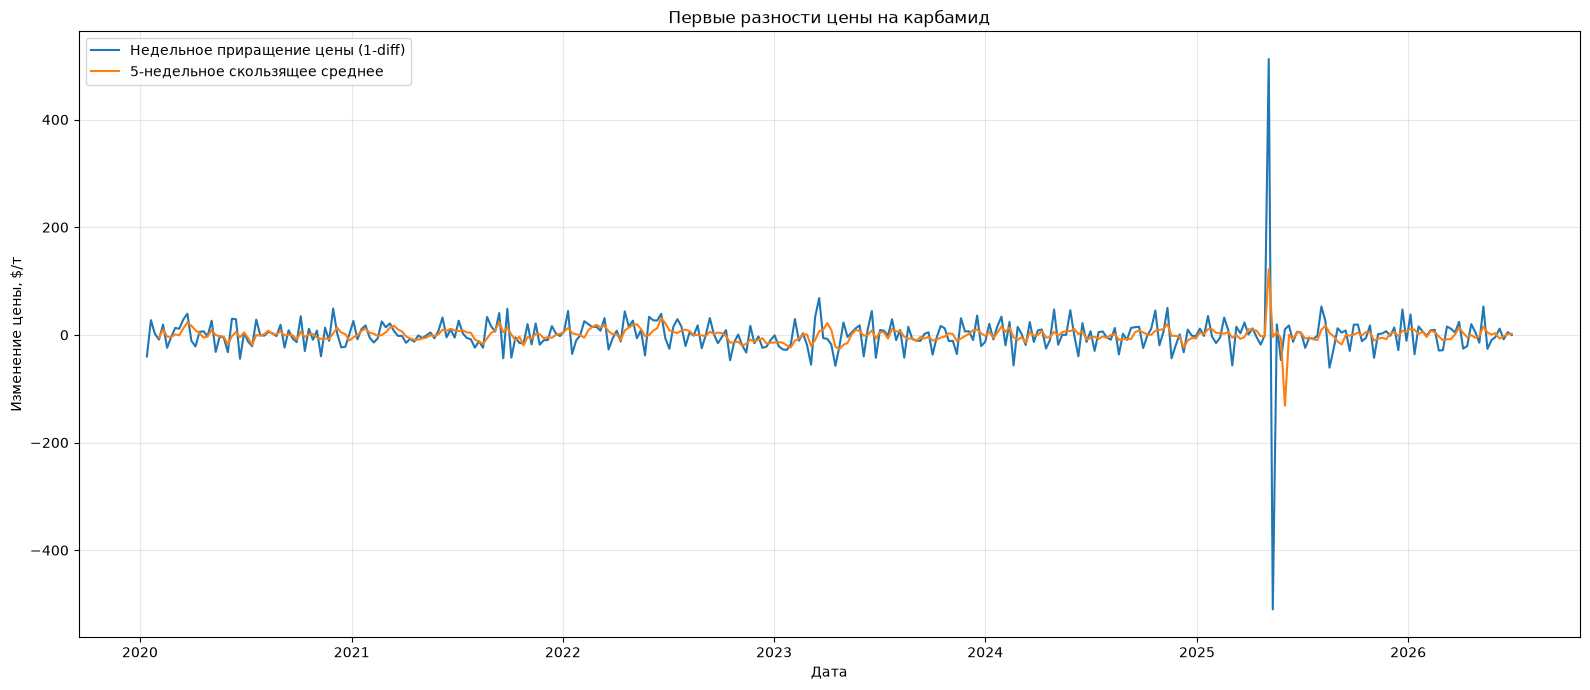

In [119]:
plt.figure(figsize=(16, 7))
plt.plot(prices.index, prices.urea_price.diff(), label='Недельное приращение цены (1-diff)')
plt.plot(prices.index, prices.urea_price.diff().rolling(4).mean(), label='5-недельное скользящее среднее')
plt.title('Первые разности цены на карбамид')
plt.xlabel('Дата')
plt.ylabel('Изменение цены, $/т')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

Ряд первых разностей выглядит значительно более стационарным, чем исходный ряд цен: значения колеблются вокруг нуля, выраженный тренд отсутствует, а разброс остается примерно одинаковым на протяжении всего периода, за исключением отдельных резких скачков. Скользящее среднее также остается близким к нулю.

In [29]:
reg_diff_model = LinearRegression()
evaluator.evaluate(
    reg_diff_model, 
    X_train.ffill(), 
    y_train, 
    name='LinReg (Diff)', 
    target_transform='diff'
)
evaluator.print_summary('LinReg (Diff)')


Сводная оценка для LinReg (Diff)
  MAE : mean = 29.8987 +- 10.9469  [фолды: 45.4902, 32.3338, 15.0614, 26.7093]
  MAPE: mean = 0.0608 +- 0.0209  [фолды: 0.0950, 0.0558, 0.0385, 0.0538]
  RMSE: mean = 54.6883 +- 27.5802  [фолды: 86.4572, 36.5535, 19.4847, 76.2580]


In [30]:
cat_diff_model = CatBoostRegressor(
    iterations=2000,
    depth=6,
    loss_function="MAE",
    random_seed=123
)
evaluator.evaluate(
    cat_diff_model, 
    X_train, 
    y_train, 
    name='CatBoost (Diff)', 
    target_transform='diff'
)
evaluator.print_summary('CatBoost (Diff)')


Сводная оценка для CatBoost (Diff)
  MAE : mean = 21.1769 +- 6.7090  [фолды: 15.5496, 19.2300, 17.3513, 32.5766]
  MAPE: mean = 0.0456 +- 0.0135  [фолды: 0.0344, 0.0358, 0.0440, 0.0681]
  RMSE: mean = 41.0235 +- 32.7902  [фолды: 20.1440, 24.3711, 21.8209, 97.7579]


In [31]:
evaluator.get_summary_df().sort_values(by='MAE')

,Model,MAE,MAPE,RMSE
4,CatBoost (Diff),21.176899,0.045568,41.023480
0,Naive1Step,21.809649,0.047058,41.437496
1,LinReg (Base),29.898666,0.060773,54.688334
3,LinReg (Diff),29.898666,0.060773,54.688334
2,CatBoost (Base),51.863877,0.097183,73.403539


Переход к прогнозированию приращений (`target_transform='diff'`) позволил CatBoost значительно улучшить результат. Его ошибка (MAE) снизилась с 51.86 до 21.18, что позволило впервые побить наивный бейзлайн (21.81). Ошибка линейной регрессии не изменилась, так как математически прогнозирование разностей для нее означает лишь сдвиг коэффициентов. Теперь, когда у нас есть сильная базовая модель, перейдем к Feature Engineering, где добавим лаги и скользящие статистики.

### Feature Engineering

In [32]:
df = prices.copy().ffill() 

df['target'] = df.urea_price.shift(-1)
df = df.dropna(subset='target')

df["month_sin"] = np.sin(2 * np.pi * df.index.month / 12)
df["month_cos"] = np.cos(2 * np.pi * df.index.month / 12)

for lag in [1, 2, 4, 8]:
    df[f"urea_lag_{lag}"] = df['urea_price'].shift(lag)

exog_features = [
    "gas_price",
    "ammonia_price",
    "crop_price_index"
]

for w in [4, 8]:
    df[f"urea_roll_mean_{w}"] = df.urea_price.rolling(w).mean()
    df[f"urea_roll_std_{w}"] = df.urea_price.rolling(w).std()

    for col in exog_features:
        df[f"{col}_roll_mean_{w}"] = df[col].rolling(w).mean()
        df[f"{col}_roll_std_{w}"] = df[col].rolling(w).std()

for col in exog_features:
    for lag in [1, 2, 4]:
        df[f"{col}_lag_{lag}"] = df[col].shift(lag)

df["urea_pct_change_1"] = df.urea_price.pct_change()
df["urea_pct_change_4"] = df.urea_price.pct_change(4)
df['urea_ewm_mean_4'] = df.urea_price.ewm(span=4).mean()

df["urea_diff_1"] = df.urea_price.diff()
df["urea_diff_lag_1"] = df["urea_diff_1"].shift(1)
df["gas_diff_1"] = df.gas_price.diff()
df["ammonia_diff_1"] = df.ammonia_price.diff()

df = df.dropna()

In [33]:
df.head(3)

,urea_price,dap_price,mop_price,gas_price,ammonia_price,brent_oil,usd_rub,freight_index,crop_price_index,sulphur_price,...,crop_price_index_lag_1,crop_price_index_lag_2,crop_price_index_lag_4,urea_pct_change_1,urea_pct_change_4,urea_ewm_mean_4,urea_diff_1,urea_diff_lag_1,gas_diff_1,ammonia_diff_1
date,,,,,,,,,,,,,,,,,,,,,
2020-03-02,362.7,582.0,482.3,23.9,474.1,59.1,64.14,1844.0,100.6,177.7,...,105.1,103.9,106.4,0.036878,0.011433,359.409679,12.9,-4.0,0.7,28.5
2020-03-09,374.1,565.4,452.7,22.4,433.0,58.5,62.05,1909.0,102.7,161.0,...,100.6,105.1,104.2,0.031431,-0.009794,365.321554,11.4,12.9,-1.5,-41.1
2020-03-16,402.6,585.2,464.1,25.4,492.7,53.7,62.38,1909.0,108.1,161.0,...,102.7,100.6,103.9,0.076183,0.137931,380.287228,28.5,11.4,3.0,59.7


In [34]:
features = df.drop(columns=['target', 'consensus_price_urea'])
target = df.target

X_train, X_test, y_train, y_test = time_series_split(features, target)

X_train.shape, X_test.shape

((280, 50), (50, 50))

In [35]:
evaluator.evaluate(
    LinearRegression(), 
    X_train, 
    y_train, 
    name='LinReg (Features, Diff)', 
    target_transform='diff'
)
evaluator.print_summary('LinReg (Features, Diff)')


Сводная оценка для LinReg (Features, Diff)
  MAE : mean = 52.7355 +- 23.7971  [фолды: 64.1530, 85.6983, 24.9106, 36.1801]
  MAPE: mean = 0.1083 +- 0.0389  [фолды: 0.1385, 0.1546, 0.0638, 0.0764]
  RMSE: mean = 78.5919 +- 29.2350  [фолды: 93.0730, 108.8793, 30.8146, 81.6006]


In [36]:
cat_feat_model = CatBoostRegressor(
    iterations=2000,
    depth=6,
    loss_function="MAE",
    random_seed=123
)

evaluator.evaluate(
    cat_feat_model, 
    X_train, 
    y_train, 
    name='CatBoost (Features, Diff)', 
    target_transform='diff'
)
evaluator.print_summary('CatBoost (Features, Diff)')


Сводная оценка для CatBoost (Features, Diff)
  MAE : mean = 20.9256 +- 6.1135  [фолды: 16.0240, 19.2072, 17.1430, 31.3282]
  MAPE: mean = 0.0448 +- 0.0120  [фолды: 0.0349, 0.0362, 0.0435, 0.0647]
  RMSE: mean = 40.9943 +- 32.4706  [фолды: 20.6949, 24.3560, 21.7388, 97.1877]


In [37]:
evaluator.get_summary_df().sort_values(by='MAE')

,Model,MAE,MAPE,RMSE
6,"CatBoost (Features, Diff)",20.925607,0.044835,40.994323
4,CatBoost (Diff),21.176899,0.045568,41.023480
0,Naive1Step,21.809649,0.047058,41.437496
1,LinReg (Base),29.898666,0.060773,54.688334
3,LinReg (Diff),29.898666,0.060773,54.688334
2,CatBoost (Base),51.863877,0.097183,73.403539
5,"LinReg (Features, Diff)",52.735504,0.108326,78.591895


### Выводы

1. **Лучший результат показал CatBoost** - **MAE = 20.93**, **MAPE = 4.48%**, немного превзойдя наивный прогноз.

2. **Feature Engineering дал небольшой эффект.** Добавление лагов и других временных признаков улучшило MAE всего с **21.18** до **20.93**.

3. **Линейная регрессия ухудшила качество** после добавления большого количества признаков, вероятно, из-за мультиколлинеарности.

Следующий этап - проверить, могут ли рыночные новости улучшить качество прогнозирования.


## EDA новостей (market_news.csv)

В этом разделе мы исследуем новостной корпус: оценим сбалансированность категорий, плотность новостного потока, длину заголовков и проанализируем взаимосвязь новостей с изменениями цен.

In [38]:
news.isna().sum()

source      0
category    0
headline    0
dtype: int64

In [39]:
print("Полных дубликатов в новостях (с учетом даты):", news.reset_index().duplicated().sum())
news_dup_count = news.reset_index().duplicated(subset=['date', 'headline']).sum()
print("Дубликатов по дате и заголовку:", news_dup_count)

Полных дубликатов в новостях (с учетом даты): 0
Дубликатов по дате и заголовку: 0


Пропуски и полные дубликаты отсутствуют. Данные чистые и готовы к анализу.

### Распределение новостей по категориям

Оценим объем публикаций в разрезе тематик.

In [40]:
news.category.value_counts()

category
Фосфаты            62
Прочее             56
Аммиак             52
Калий              48
Спрос/агрорынок    47
Логистика          44
Макро/валюта       31
Энергоносители     30
Name: count, dtype: int64

Сильного дисбаланса категорий не наблюдается

In [41]:
news.reset_index().groupby('category').first()[['date', 'headline']]

,date,headline
category,,
Аммиак,2020-03-12,Котировки аммиака пошли вниз на фоне слабого спроса
Калий,2020-04-18,Дефицит калия на ключевых рынках толкает цены вверх
Логистика,2020-01-18,"Ставки фрахта снижаются, логистика дешевеет"
Макро/валюта,2020-11-27,Девальвация рубля повышает экспортную привлекательность удобрений
Прочее,2020-01-08,Опубликован годовой ESG-отчёт компании
Спрос/агрорынок,2020-03-18,Высокие цены на агрокультуры стимулируют закупки удобрений фермерами
Фосфаты,2020-01-10,DAP дешевеет из-за слабого спроса в Индии
Энергоносители,2021-03-12,"Цены на газ в Европе снижаются, давление на себестоимость удобрений ослабевает"


### Распределение источников новостей

In [42]:
news.source.value_counts()

source
Argus                        58
CRU                          57
ICIS                         47
Профильный телеграм-канал    44
Коммерсантъ                  44
Интерфакс                    43
Reuters                      43
Bloomberg                    34
Name: count, dtype: int64

Распределение источников так же достаточно сбалансировано

### Динамика новостного потока во времени

Проанализируем еженедельную интенсивность публикаций.

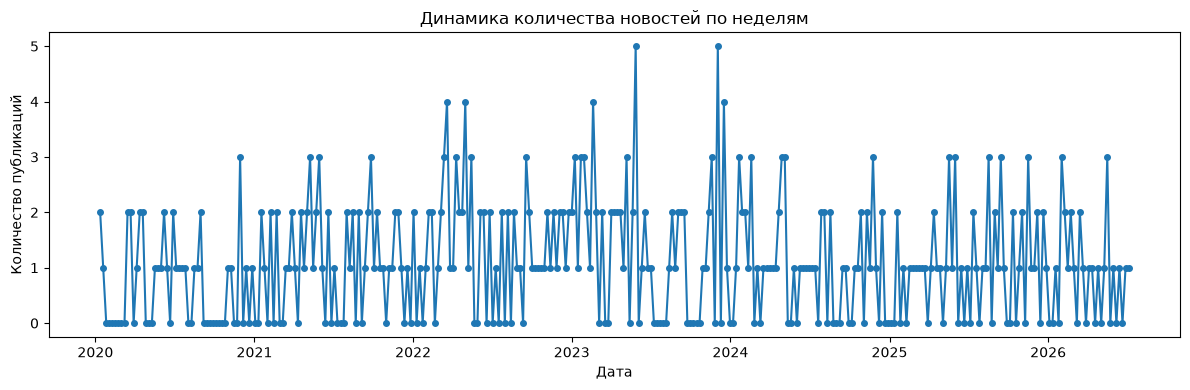

In [43]:
news_weekly_counts = news.resample('W').size()

plt.figure(figsize=(12, 4))
plt.plot(news_weekly_counts.index, news_weekly_counts.values, marker='o', markersize=4)
plt.title('Динамика количества новостей по неделям')
plt.xlabel('Дата')
plt.ylabel('Количество публикаций')
plt.tight_layout()
plt.show()

In [44]:
print(news_weekly_counts.values.mean())

1.0914454277286136


In [45]:
print(f'{(news_weekly_counts == 0).sum() / len(news_weekly_counts):.1%}')

33.9%


Плотность новостного потока крайне низкая: в среднем выходит 1.1 новость в неделю, при этом 34% недель вообще не содержат публикаций. Резкие всплески активности (до 4-5 новостей) редки и могут влиять на изменение цен.

### Анализ длины заголовков

Это важно для выбора параметров NLP-моделей векторизации.

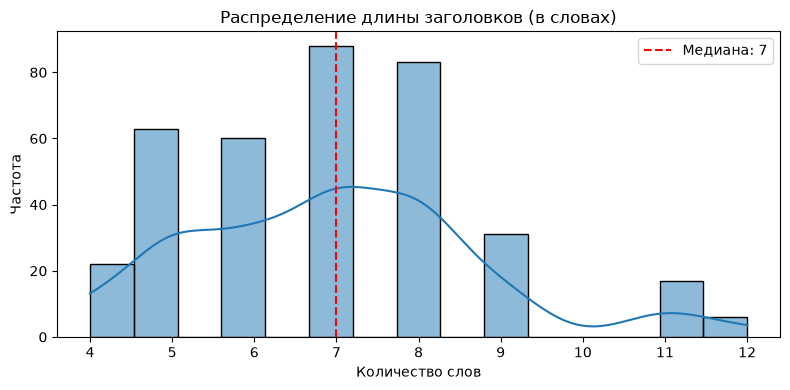

In [46]:
news['headline_len_words'] = news['headline'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8, 4))
sns.histplot(news['headline_len_words'], kde=True)
plt.title('Распределение длины заголовков (в словах)')
plt.xlabel('Количество слов')
plt.ylabel('Частота')
plt.axvline(news['headline_len_words'].median(), color='red', linestyle='--', label=f"Медиана: {int(news['headline_len_words'].median())}")
plt.legend()
plt.tight_layout()
plt.show()

Заголовки очень короткие (медианная длина - 7 слов), что позволяет использовать предобученные модели Sentence Transformers без риска обрезания ключевой информации.

### Связь тематики новостей и динамики цен карбамида

Оценим, как меняется цена на следующей неделе при наличии новостей по различным категориям.

In [47]:
news['week'] = news.index - pd.to_timedelta(news.index.weekday, unit='D')
price_change_1w = prices['urea_price'].diff().shift(-1).rename('change_1w')
news_with_target = news.join(price_change_1w, on='week')

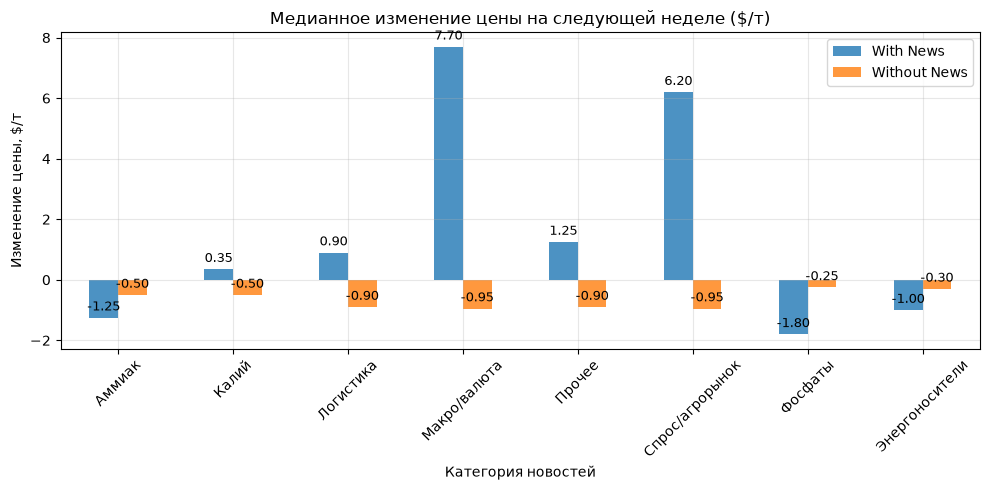

In [48]:
news_weekly_cat = news.groupby(['week', 'category']).size().unstack(fill_value=0)
price_change_aligned = price_change_1w.reindex(news_weekly_cat.index)

category_impact = []
for col in news_weekly_cat.columns:
    has_news = news_weekly_cat[col] > 0
    median_change_with = price_change_aligned[has_news].median()
    median_change_without = price_change_aligned[~has_news].median()
    category_impact.append({
        'Category': col,
        'With News': median_change_with,
        'Without News': median_change_without
    })

cat_impact_df = pd.DataFrame(category_impact).set_index('Category')

ax = cat_impact_df.plot(kind='bar', figsize=(10, 5), alpha=0.8)

plt.title('Медианное изменение цены на следующей неделе ($/т)')
plt.ylabel('Изменение цены, $/т')
plt.xlabel('Категория новостей')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

plt.tight_layout()

Использование медианы вместо среднего дает более устойчивую картину, так как цены на карбамид подвержены сильным точечным выбросам. 
Мы видим, что типичный рост цен ассоциируется с выходом новостей в категориях "Макро/валюта" (медиана +7.70 \$/т) и "Спрос/агрорынок" (+6.20 \$/т). 

### Простой лексический анализ направленности заголовков

Разделим заголовки на позитивные (сигналы роста) и негативные (сигналы падения) на основе ключевых слов.

,count,mean,median,std
direction,,,,
down,96,-1.313542,-1.70,24.275969
neutral,169,-2.408876,1.30,46.553935
up,104,3.119231,3.45,21.611935


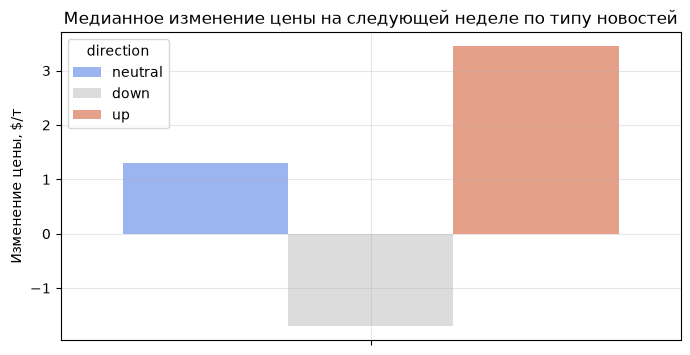

In [49]:
up_words = ['рост', 'растет', 'вверх', 'дорожает', 'дефицит', 'повышает', 'высокие', 'увеличивает', 'подъем', 'выросли', 'увеличился']
down_words = ['падение', 'падает', 'вниз', 'дешевеет', 'профицит', 'снижает', 'слабый', 'ослабевает', 'снижение', 'упали', 'сократился']

def get_direction(headline):
    text = str(headline).lower()
    up_score = sum(1 for w in up_words if w in text)
    down_score = sum(1 for w in down_words if w in text)
    if up_score > down_score:
        return 'up'
    elif down_score > up_score:
        return 'down'
    else:
        return 'neutral'

news['direction'] = news['headline'].apply(get_direction)
news_with_target['direction'] = news['direction']

direction_df = news_with_target[['direction', 'change_1w']].dropna()

plt.figure(figsize=(8, 4))
sns.barplot(data=direction_df, hue='direction', y='change_1w', estimator=np.median, errorbar=None, palette='coolwarm')
plt.title('Медианное изменение цены на следующей неделе по типу новостей')
plt.ylabel('Изменение цены, $/т')
plt.grid(True, alpha=0.3)

direction_df.groupby('direction')['change_1w'].agg(['count', 'mean', 'median', 'std'])

Простой лексический сентимент-анализ подтверждает общую логику рынка: новости с сигналами роста предшествуют росту цен и наоборот.

Тем не менее, стандартное отклонение (std) для обеих групп огромно (более 21-24 $/т), что значительно превышает средний эффект. Это означает, что хотя семантическая направленность новостей и совпадает с общим вектором рынка, этот сигнал крайне зашумлен.

### Влияние ключевых слов на динамику цен

Проанализируем отдельные слова в заголовках и сопоставим их со средним изменением цены на следующей неделе.

In [50]:
nltk.download('stopwords', quiet=True)
morph = pymorphy3.MorphAnalyzer()
russian_stopwords = stopwords.words("russian")

In [60]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\W', ' ', text)
    words = text.split()
    words = [morph.parse(w)[0].normal_form for w in words]
    words = [w for w in words if w not in russian_stopwords]
    return words

word_impact = []
for idx, row in news_with_target.dropna(subset=['change_1w']).iterrows():
    words = clean_text(row['headline'])
    for w in set(words):
        if len(w) > 3:
            word_impact.append({'word': w, 'change_1w': row['change_1w'], 'count': 1})

word_stats = pd.DataFrame(word_impact).groupby('word').agg(
    count=('count', 'sum'),
    mean_change_1w=('change_1w', 'mean')
).reset_index()

word_stats_filtered = word_stats[word_stats['count'] >= 5]
word_stats_filtered.sort_values(by='mean_change_1w', ascending=False).head()

,word,count,mean_change_1w
19,девальвация,7,24.557143
89,привлекательность,7,24.557143
79,повышать,7,24.557143
62,неделя,7,17.400000
11,второй,7,17.400000


In [85]:
word_stats_filtered.sort_values(by='mean_change_1w', ascending=True).head()

,word,count,mean_change_1w
30,заключить,12,-57.116667
62,ниже,12,-57.116667
44,контракт,12,-57.116667
40,калия,12,-57.116667
64,новый,23,-26.034783


В целом, словесные маркеры выглядят логично и отражают базовые драйверы рынка (например, позитивное влияние девальвации или экспортных ограничений). Однако делать вывод о том, что это сильный опережающий сигнал, пока рано — новости могут просто констатировать факты, которые рынок уже отыграл. 
Дальше попробуем использовать эмбеддинги Sentence Transformer, чтобы передать смысл текстов в CatBoost.

### Взаимная корреляция (Lead/Lag анализ)
Проверим, действительно ли новости опережают изменения цен, или просто выходят по факту роста цен (Causation vs Correlation).

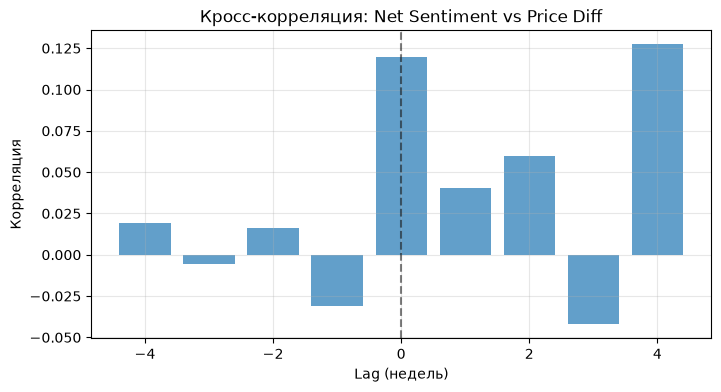

In [76]:
news_with_target

In [ ]:
sentiment_weekly = news_with_target.groupby(['week', 'direction']).size().unstack(fill_value=0)
if 'up' in sentiment_weekly.columns and 'down' in sentiment_weekly.columns:
    sentiment_weekly['net_sentiment'] = sentiment_weekly['up'] - sentiment_weekly['down']
    
    merged_ts = prices[['urea_price']].join(sentiment_weekly['net_sentiment']).fillna(0)
    merged_ts['price_diff'] = merged_ts['urea_price'].diff()
    
    lags = range(-4, 5)
    corrs = []
    for lag in lags:
        # lag > 0: sentiment сдвинут вперед (новости предсказывают цену)
        # lag < 0: sentiment сдвинут назад (новости реагируют на цену)
        corr = merged_ts['net_sentiment'].shift(lag).corr(merged_ts['price_diff'])
        corrs.append(corr)
        
    plt.figure(figsize=(8, 4))
    plt.bar(lags, corrs, alpha=0.7)
    plt.axvline(0, color='black', linestyle='--', alpha=0.5)
    plt.title('Кросс-корреляция: Net Sentiment vs Price Diff')
    plt.xlabel('Lag (недель). Положительный = новости ОПЕРЕЖАЮТ цены')
    plt.ylabel('Корреляция')
    plt.grid(True, alpha=0.3)
    plt.show()

Анализ взаимной корреляции (кросс-корреляции) дает важные инсайты:
- Одновременная корреляция (Lag = 0) составляет всего ~0.12, что указывает на очень слабую связь сентимента новостей с движением цен на той же неделе.
- На лаге 1 неделя (Lag = 1, новости пытаются предсказать цену будущего периода) корреляция падает до незначительных 0.04.

Это математическое подтверждение того, что публичные новости не несут опережающего сигнала для прогнозирования цен на следующую неделю. Скорее, они просто констатируют факты текущей недели (Lag = 0), что объясняет, почему модели машинного обучения не получают значимого прироста от текстовых признаков.

## Интеграция текстовых признаков в модель (NLP + CatBoost)

Теперь добавим текстовые фичи в модель и посмотрим, дадут ли они какой-то прирост. Попробуем два подхода:
1. **TF-IDF:** просто посмотрим, какие конкретно слова сильнее всего влияют на модель (ради интерпретируемости).
2. **Эмбеддинги (SentenceTransformer) + PCA:** попытаемся выжать максимум из семантики текстов, добавив к этому частоту выхода новостей по категориям.

Прогоним все конфигурации на кросс-валидации и сравним с базовой моделью, которая смотрит только на цены.

In [79]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [80]:
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer

Генерация недельных признаков из новостей.

In [ ]:
def build_weekly_news_features(news_df):

    df = news_df.copy()
    
    # Тексты для эмбеддингов
    df["text"] = df["category"].fillna("") + " " + df["headline"].fillna("") + " " + df["source"].fillna("")
    
    # Количество новостей за неделю по категориям
    news_weekly_cat = df.groupby(['week', 'category']).size().unstack(fill_value=0)
    news_weekly_cat.columns = [f"news_cat_{c}" for c in news_weekly_cat.columns]
    
    # TF-IDF с лемматизацией и удалением стоп-слов
    def clean_and_lemmatize(text):
        text = str(text).lower()
        text = re.sub(r'\W', ' ', text)
        words = text.split()
        words = [morph.parse(w)[0].normal_form for w in words]
        return " ".join(words)

    df["cleaned_headline"] = df["headline"].apply(clean_and_lemmatize)
    
    tfidf_vec = TfidfVectorizer(max_features=200, min_df=2, ngram_range=(1,2), stop_words=russian_stopwords)
    tfidf_matrix = tfidf_vec.fit_transform(df["cleaned_headline"]).toarray()
    tfidf_df = pd.DataFrame(
        tfidf_matrix,
        columns=[f"tfidf_{w}" for w in tfidf_vec.get_feature_names_out()],
        index=df.index
    )
    tfidf_df["week"] = df['week']

    weekly_tfidf = tfidf_df.groupby("week").sum()
    
    # SentenceTransformer для семантического анализа
    model_st = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

    embeddings = model_st.encode(
        df["text"].tolist(),
        show_progress_bar=True,
        convert_to_numpy=True
    )
    
    emb_df = pd.DataFrame(
        embeddings,
        columns=[f"text_emb_{i}" for i in range(embeddings.shape[1])],
        index=df.index
    )
    emb_df["week"] = df['week']

    weekly_embeddings = emb_df.groupby("week").mean()
    
    return news_weekly_cat, weekly_tfidf, weekly_embeddings

news_weekly_cat, weekly_tfidf, weekly_embeddings = build_weekly_news_features(news)
print("Форма признаков категорий:", news_weekly_cat.shape)
print("Форма признаков TF-IDF:", weekly_tfidf.shape)
print("Форма эмбеддингов:", weekly_embeddings.shape)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/12 [00:00<?, ?it/s]

Форма признаков категорий: (224, 8)
Форма признаков TF-IDF: (224, 200)
Форма эмбеддингов: (224, 384)


Создание финального датасета объединением цен и новостей по неделям.

In [83]:
def build_master_dataset(price_features, extra_features_df):

    merged = price_features.merge(extra_features_df, left_index=True, right_index=True, how="left")
    extra_cols = list(extra_features_df.columns)
    merged[extra_cols] = merged[extra_cols].fillna(0)
    
    X = merged.drop(columns=['target', 'consensus_price_urea'])
    y = merged.target
    
    return X, y

In [84]:
experiments = [
    ("CatBoost (Tabular + News Categories)", news_weekly_cat, False),
    ("CatBoost (Tabular + TF-IDF)", weekly_tfidf, False),
    ("CatBoost (Tabular + ST Embeddings Raw)", weekly_embeddings, False),
    ("CatBoost (Tabular + PCA Embeddings)", weekly_embeddings, True),
    ("CatBoost (Tabular + PCA + News Categories)", 
     weekly_embeddings.merge(news_weekly_cat, left_index=True, right_index=True, how="left").fillna(0), True)
]

for model_name, extra_features, use_pca in experiments:
    
    if extra_features is None:
        X_eval, y_eval = X_train, y_train
    else:
        X_merged, y_merged = build_master_dataset(df, extra_features)
        X_eval, _, y_eval, _ = time_series_split(X_merged, y_merged)
        
    preprocessor = None
    if use_pca:
        text_cols = [c for c in X_eval.columns if c.startswith('text_emb_')]
        preprocessor = ColumnTransformer(
            transformers=[('pca', PCA(n_components=20, random_state=123), text_cols)],
            remainder='passthrough',
            verbose_feature_names_out=False
        ).set_output(transform="pandas")
        
    evaluator.evaluate(
        CatBoostRegressor(iterations=2000, depth=6, loss_function="MAE", random_seed=123),
        X_eval, y_eval, 
        name=model_name, 
        target_transform='diff', 
        preprocessor=preprocessor
    )

Исключим газ и аммиак, чтобы проверить, справляется ли текстовая модель (TF-IDF) без них.

In [85]:
X_tfidf, y_tfidf = build_master_dataset(df, weekly_tfidf)
X_train_tfidf, _, y_train_tfidf, _ = time_series_split(X_tfidf, y_tfidf)

X_ablation_tfidf = X_train_tfidf.drop(columns=[c for c in X_train_tfidf.columns if 'gas' in c or 'ammonia' in c])
evaluator.evaluate(CatBoostRegressor(iterations=2000, depth=6, loss_function="MAE", random_seed=123),
                   X_ablation_tfidf, y_train_tfidf, name="CatBoost (TF-IDF without Gas/Ammonia)", target_transform='diff');

In [86]:
X_ablation_tfidf.shape

(280, 232)

In [87]:
evaluator.get_summary_df().sort_values(by='MAE')

,Model,MAE,MAPE,RMSE
6,"CatBoost (Features, Diff)",20.925607,0.044835,40.994323
11,CatBoost (Tabular + PCA + News Categories),21.037787,0.045218,41.221592
7,CatBoost (Tabular + News Categories),21.074726,0.045246,41.241984
4,CatBoost (Diff),21.176899,0.045568,41.023480
10,CatBoost (Tabular + PCA Embeddings),21.177995,0.045612,41.162074
12,CatBoost (TF-IDF without Gas/Ammonia),21.264814,0.045720,40.838866
8,CatBoost (Tabular + TF-IDF),21.268165,0.045719,41.114086
9,CatBoost (Tabular + ST Embeddings Raw),21.506542,0.046231,41.452893
0,Naive1Step,21.809649,0.047058,41.437496
1,LinReg (Base),29.898666,0.060773,54.688334


### Интерпретация TF-IDF признаков (Важность слов)

TOP-20 TF-IDF features by SHAP (Mean Absolute Impact):
tfidf_удобрение              0.786261
tfidf_экспортный             0.330256
tfidf_рубль                  0.305788
tfidf_контракт калия         0.281778
tfidf_калия                  0.277537
tfidf_снижаться              0.226932
tfidf_заключить ниже         0.187790
tfidf_новый контракт         0.173219
tfidf_аммиак                 0.166621
tfidf_цена                   0.162197
tfidf_новый                  0.151452
tfidf_спрос                  0.113734
tfidf_рынок                  0.111170
tfidf_сокращение мощность    0.081941
tfidf_котировка фосфатный    0.081589
tfidf_удобрение фермер       0.078206
tfidf_контракт               0.078039
tfidf_слабый спрос           0.076610
tfidf_спрос удобрение        0.071514
tfidf_фосфатный              0.070513
dtype: float64


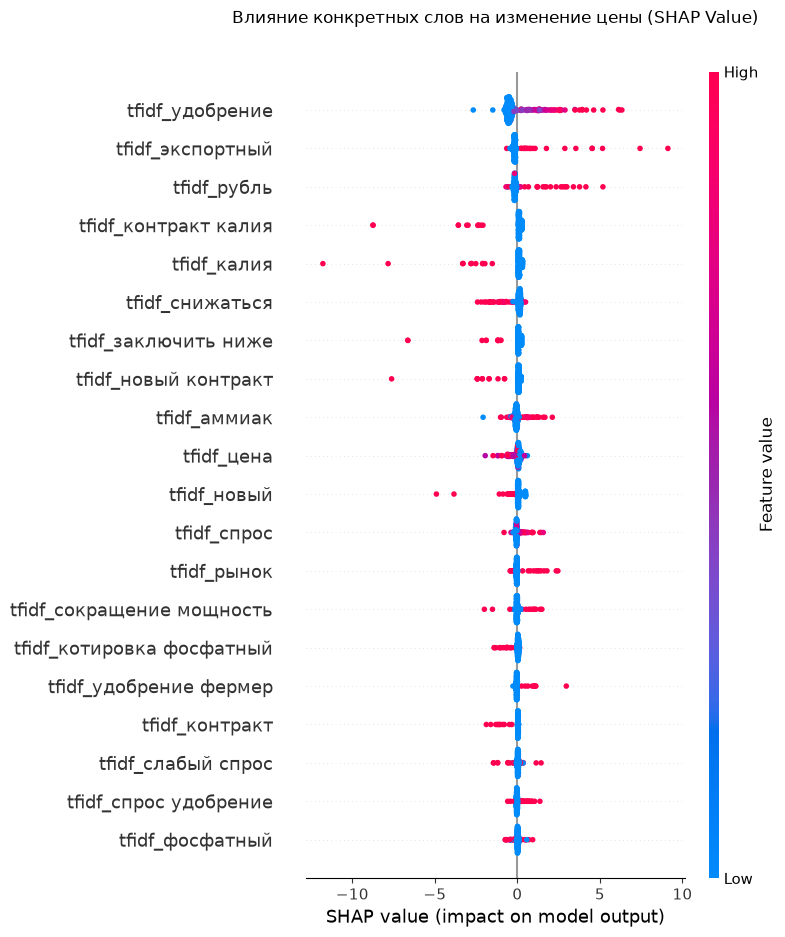

In [96]:
model_tfidf = CatBoostRegressor(iterations=1000, depth=6, loss_function="MAE", random_seed=123, verbose=False)
y_train_diff_tfidf = y_train_tfidf - X_train_tfidf['urea_price']
model_tfidf.fit(X_train_tfidf, y_train_diff_tfidf)

explainer = shap.TreeExplainer(model_tfidf)
shap_values = explainer.shap_values(X_train_tfidf)

shap_importance = np.abs(shap_values).mean(axis=0)
shap_series = pd.Series(shap_importance, index=X_train_tfidf.columns)

text_shap = shap_series[shap_series.index.str.startswith('tfidf_')].sort_values(ascending=False).head(20)

print("TOP-20 TF-IDF features by SHAP (Mean Absolute Impact):")
print(text_shap)

top_text_cols = text_shap.index.tolist()
col_indices = [X_train_tfidf.columns.get_loc(c) for c in top_text_cols]

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values[:, col_indices], X_train_tfidf[top_text_cols], show=False)
plt.title('Влияние конкретных слов на изменение цены (SHAP Value)', y=1.05)
plt.tight_layout()
plt.show()

По SHAP видно, что модель действительно пытается цепляться за логичные триггеры: экспорт, валютный курс, контракты. Но при этом в топе довольно много шумовых признаков. Это ожидаемо для простого TF-IDF — он выхватывает отдельные слова, но совершенно не понимает их контекст.

### Анализ ошибок (Error Analysis)
Выявим периоды, где модель (лучший бейзлайн) ошибается сильнее всего.


Топ-10 крупнейших ошибок прогноза (Out-of-Fold):
            True_Price  Predicted_Price       Error   Abs_Error
date                                                           
2025-04-28       922.0       408.178617 -513.821383  513.821383
2025-05-05       412.0       907.717091  495.717091  495.717091
2023-03-13       488.7       419.449449  -69.250551   69.250551
2024-11-04       462.1       404.812488  -57.287512   57.287512
2023-04-10       399.8       456.721473   56.921473   56.921473
2021-09-20       497.8       444.430316  -53.369684   53.369684
2023-02-27       387.2       439.674227   52.474227   52.474227
2024-05-20       440.3       392.744102  -47.555898   47.555898
2022-10-10       656.9       703.798797   46.898797   46.898797
2022-01-03       473.1       426.290879  -46.809121   46.809121


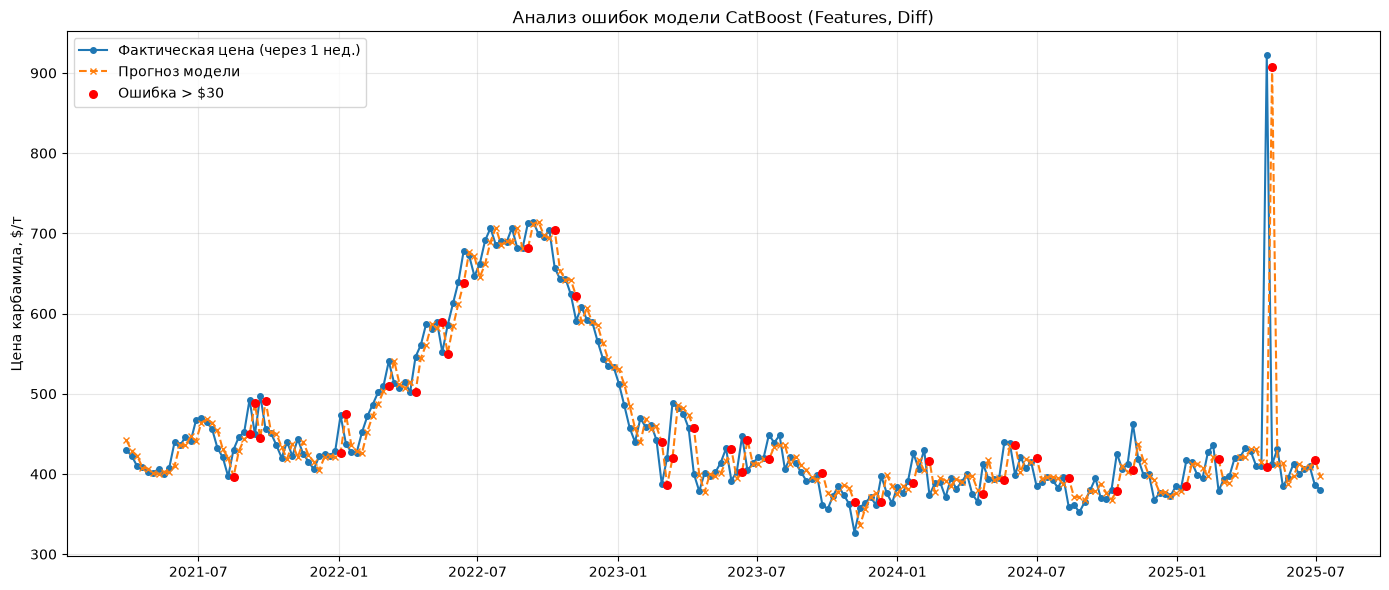

In [93]:
best_model_name = "CatBoost (Features, Diff)" 

res = evaluator.results[best_model_name]

all_val_idx = np.concatenate(res["val_indices"])
all_preds = np.concatenate(res["predictions"])

df_errors = pd.DataFrame({
    'True_Price': y_train.iloc[all_val_idx].values,
    'Predicted_Price': all_preds
}, index=y_train.iloc[all_val_idx].index)

df_errors['Error'] = df_errors['Predicted_Price'] - df_errors['True_Price']
df_errors['Abs_Error'] = df_errors['Error'].abs()

df_errors = df_errors.sort_index()

print("\nТоп-10 крупнейших ошибок прогноза (Out-of-Fold):")
print(df_errors.sort_values(by='Abs_Error', ascending=False).head(10))

plt.figure(figsize=(14, 6))
plt.plot(df_errors.index, df_errors['True_Price'], label='Фактическая цена (через 1 нед.)', marker='o', markersize=4)
plt.plot(df_errors.index, df_errors['Predicted_Price'], label='Прогноз модели', marker='x', markersize=4, linestyle='--')

# Выделяем красным зоны сильных ошибок (> 30 долларов)
large_errors = df_errors[df_errors['Abs_Error'] > 30]
plt.scatter(large_errors.index, large_errors['Predicted_Price'], color='red', s=30, zorder=2, label='Ошибка > $30')

plt.title(f'Анализ ошибок модели {best_model_name}')
plt.ylabel('Цена карбамида, $/т')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

### Финальное тестирование на отложенной выборке (Test Evaluation)
Оценим качество лучшей модели (`CatBoost (Features, Diff)`) на тестовой выборке `X_test`, которая не участвовала в подборе гиперпараметров и кросс-валидации.
Для этого обучим модель на всей обучающей выборке `X_train` и сделаем прогноз для `X_test`.

In [ ]:
best_model = CatBoostRegressor(
    iterations=2000,
    depth=6,
    loss_function="MAE",
    random_seed=123,
    verbose=False
)

y_train_diff = y_train - X_train['urea_price']
best_model.fit(X_train, y_train_diff)

test_preds_diff = best_model.predict(X_test)

# Восстанавливаем абсолютные цены
test_preds_eval = X_test['urea_price'].values + test_preds_diff

# Расчет финальных метрик
test_mae = mae(y_test, test_preds_eval)
test_mape = mape(y_test, test_preds_eval)
test_rmse = rmse(y_test, test_preds_eval)

print("Качество лучшей модели на отложенной тестовой выборке:")
print(f"  MAE  = {test_mae:.2f} $/т")
print(f"  MAPE = {test_mape:.2%}%")
print(f"  RMSE = {test_rmse:.2f} $/т")

# Сравнение с наивным прогнозом на тесте
naive_test_preds = X_test['urea_price'].values

naive_test_mae = mae(y_test, naive_test_preds)
naive_test_mape = mape(y_test, naive_test_preds)
naive_test_rmse = rmse(y_test, naive_test_preds)

print("\nКачество наивного прогноза (Naive 1-step) на тестовой выборке:")
print(f"  MAE  = {naive_test_mae:.2f} $/т")
print(f"  MAPE = {naive_test_mape:.2%}%")
print(f"  RMSE = {naive_test_rmse:.2f} $/т")

Качество лучшей модели на отложенной тестовой выборке:
  MAE  = 16.37 $/т
  MAPE = 4.21%%
  RMSE = 21.34 $/т

Качество наивного прогноза (Naive 1-step) на тестовой выборке:
  MAE  = 17.81 $/т
  MAPE = 4.54%%
  RMSE = 23.16 $/т


### Финальные выводы

Лучше всего себя показал обычный CatBoost на табличных данных (исторические цены, сырье) с лаговыми признаками и скользящими статистиками.

Самые большие промахи модели приходятся на резкое изменение цены. Например, весной 2025 года произошел разовый скачок цены до $922. Модель, глядя на предыдущие спокойные значения, дала прогноз ~$408. А на следующей неделе, "увидев" в лагах 922, она спрогнозировала продолжение высоких цен, хотя рынок уже схлопнулся обратно. Это классическая проблема авторегрессионных моделей — они всегда будут запаздывать на один шаг при резких выбросах.

Изначальная гипотеза заключалась в том, что новости помогут предсказывать такие шоки. Но на практике новости оказались малополезными для прогноза, по двум причинам:
- В открытые новости важная информация попадает уже постфактум, когда цена уже изменилась. 
- Новостей в нашем корпусе было слишком мало (около 1.1 новости в неделю).